In [1]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sympy import *
import matplotlib.pyplot as plt
import time as tm
start_time = tm.time()
init_printing(use_latex=true)
filename = "Data/T41w0s.xlsx"

In [2]:
# Choose highest degree of polynomial
k = 3

In [3]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [4]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

In [5]:
zReal = pd.read_excel(filename, sheet_name="OnOff").to_numpy().T
zReal

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.5 , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.6 , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ,
        1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.07, 0

In [6]:
dReal = pd.read_excel(filename, sheet_name="Measured").to_numpy().T
dTotal = np.sum(dReal)
dReal

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

In [7]:
# Establish vector of actual mass flows
mReal = pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T
mReal

array([[  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         70.3, 143.1, 140.6, 138.4, 136.4, 134.7, 133.5, 132.7, 132. ,
        130.8, 127.3, 123.8, 122.4, 121.5, 120.8, 120.1, 119.6, 119.1,
        118.7, 118.2, 117.5, 116.7, 116.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         65.5, 133.1, 130.6, 128.4, 126.4, 124.7, 123.5, 122.7, 122. ,
        120.8, 117.3, 113.8, 112.4, 111.5, 110.8, 110.1, 109.6, 109.1,
        108.7, 108.2, 107.5, 106.7, 106.1],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
          0. ,   0. ,  36. ,  61.9,  61.5,  60.2,  59.6,  59.2,  58.9,
         58.5,  57.7,  56.5,  55.8,  55.3,  55. ,  54.8,  54.6,  54.3,
         54.1,  54. ,  53.8,  53.6,  53.5],
       [  0. ,  

In [8]:
# Establish matrix / vector of total mass flow
MReal = pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T
MReal

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e-02, 1.3581e+02, 2.7619e+02,
        3.0720e+02, 3.2859e+02, 3.2784e+02, 3.5956e+02, 3.6559e+02,
        3.6327e+02, 3.6132e+02, 3.5823e+02, 3.8531e+02, 4.8247e+02,
        4.8156e+02, 4.7819e+02, 4.7564e+02, 4.7344e+02, 4.7156e+02,
        4.6985e+02, 4.6827e+02, 4.6642e+02, 4.6429e+02, 4.6196e+02,
        4.6039e+02]])

In [9]:
Lambda1 = 135.13 + 25
Lambda2 = 7.52 - 2
Lambda3 = 0
Lambda1, Lambda2, Lambda3

In [10]:
# Compile the y vector (col. vec.)
y = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), 1])
for j in range(T):
    # fill in m values
    for i in range(n):
        y[T*i+j, 0] = mReal[i,j] * np.sqrt(Lambda1) * dReal[i,j]  # Seems to have no effect on result but will affect RMSE score
    # fill in M values
    y[T*n+j, 0] = MReal[0,j]
y.shape

In [11]:
# Compile the A1 matrix
A1 = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), n*T])
for i in range(n):
    for j in range(T):
        # fill in d values
        A1[T*i+j, T*i+j] = np.sqrt(Lambda1) * dReal[i,j]
        # fill in z values
        A1[T*n+j, T*i+j] = zReal[i,j]
        # fill in forward difference formula to approximate the first order derivative
        if j > 0: # Ignore first row to not add a BC
            A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j-1] = -1 * np.sqrt(Lambda2)
            A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j] = 1 * np.sqrt(Lambda2)
        # fill in second order central difference formula to approximate the second order derivative
        if j > 1: # Ignore first two rows to not add BCs
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-2] = 1 * np.sqrt(Lambda3)
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-1] = -2 * np.sqrt(Lambda3)
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j] = 1 * np.sqrt(Lambda3)
            
        
    
A1.shape
#A1[638:,201:]

In [12]:
# Compile the A2 matrix
# Use t's uniformly spaced 1 apart
ts = np.array(list(range(T)))+1
A2 = np.zeros([n*T, n*(k+1)])
for block in range(n):
    for r in range(T):
        for c in range(k+1):
            A2[block*T + r, block*(k+1) + c] = ts[r]**c

A2.shape

In [13]:
# Calculate final A matrix
A = np.matmul(A1,A2)
A.shape

In [14]:
res, _, _, _ = lstsq(A, y)
res = res.reshape(n, k+1)
res

array([[ 1.51332592e+02,  2.13549925e+00, -1.86552917e-01,
         2.83578203e-03],
       [ 1.33350339e+02,  8.93761009e-01, -6.87029577e-02,
         7.42728643e-04],
       [ 6.36771128e+01,  4.39531534e-01, -3.47770499e-02,
         4.34028672e-04],
       [ 5.02063161e+01,  2.07078965e-01, -1.44990607e-02,
         1.10131885e-04],
       [ 1.42782148e+02,  7.94366895e-02, -5.61520159e-03,
         5.94803295e-05]])

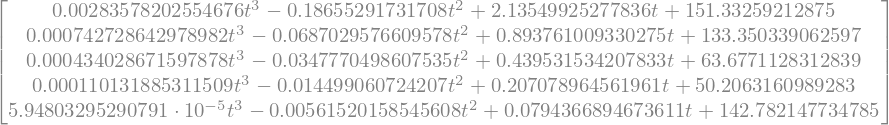

In [15]:
# Coerce results into desired format for printing
t = symbols('t')
wExpr = Matrix(np.zeros(n))
for i in range(n):
    for deg in range(k+1):
        #print(res[i,deg]*t**deg)
        wExpr[i] = wExpr[i] + res[i,deg]*t**deg

wExpr

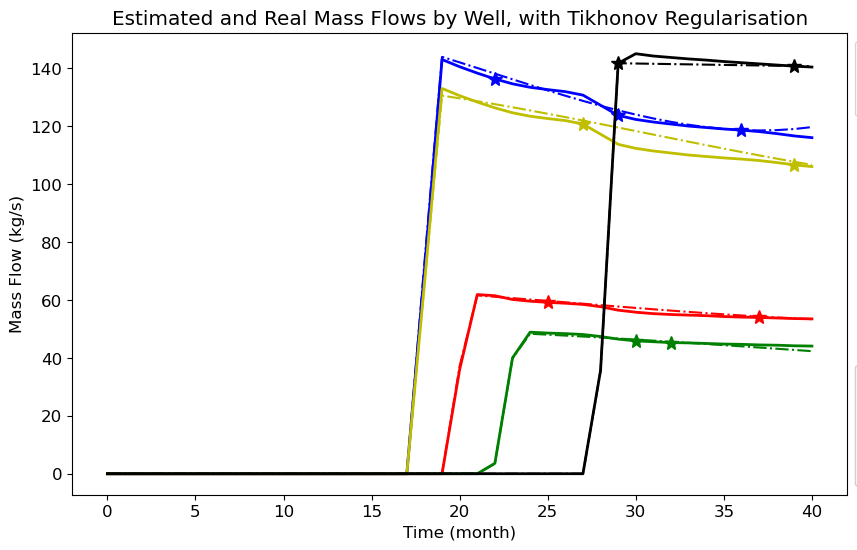

In [20]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k']
lines=[]
for i in range(n):
    l1, = plt.plot(range(T),mReal[i,:][:], colours[i]+'-', lw=2, label="Real flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for time in range(T):
        resplot = wExpr[i].subs(t, time)
        toplot.append(resplot*zReal[i,time])
        #print(time, toplot)
    l2, = plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(dReal[i,:]):
        if element==1:
            monthplot.append(month)
            tftplot.append(mReal[i,month])
    l3, = plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
    lines.append([l1,l2,l3])    
plt.title("Estimated and Real Mass Flows by Well, with Tikhonov Regularisation")
plt.xlabel("Time (month)")
plt.ylabel("Mass Flow (kg/s)")

legend1 = plt.legend(lines[0], ["True Data", "Model Estimate", "TFT Point Provided"], bbox_to_anchor=(1., 1.0), loc='upper left')
legend2 = plt.legend([l[0] for l in lines], ["Well 1", "Well 2", "Well 3", "Well 4", "Well 5"], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.gca().add_artist(legend1)
plt.gca().add_artist(legend2)
plt.rcParams['font.size'] = 15

plt.savefig("LLSOOptA.svg", bbox_inches='tight', pad_inches=4)


0 [0, 0, 0, 0, 0]
1 [0, 0, 0, 0, 0]
2 [0, 0, 0, 0, 0]
3 [0, 0, 0, 0, 0]
4 [0, 0, 0, 0, 0]
5 [0, 0, 0, 0, 0]
6 [0, 0, 0, 0, 0]
7 [0, 0, 0, 0, 0]
8 [0, 0, 0, 0, 0]
9 [0, 0, 0, 0, 0]
10 [0, 0, 0, 0, 0]
11 [0, 0, 0, 0, 0]
12 [0, 0, 0, 0, 0]
13 [0, 0, 0, 0, 0]
14 [0, 0, 0, 0, 0]
15 [0, 0, 0, 0, 0]
16 [0, 0, 0, 0, 0]
17 [0, 0, 0, 0, 0]
18 [72.9333571205078, 65.7549361971226, 0, 0, 0]
19 [144.012103693299, 130.624406286460, 0, 0, 0]
20 [142.107666461860, 129.686205328651, 37.2174917663533, 0, 0]
21 [140.170417238852, 128.699725892679, 61.5901355887240, 0, 0]
22 [138.217370716429, 127.669424350400, 61.1362517464257, 3.42420345705006, 0]
23 [136.265541586745, 126.599757073672, 60.6701055890568, 39.8840651236531, 0]
24 [134.331944541951, 125.495180434354, 60.1943012886469, 48.3472154538185, 0]
25 [132.433594274202, 124.360150804302, 59.7114430172256, 48.0421879683403, 0]
26 [130.587505475652, 123.199124555375, 59.2241349468225, 47.7246821442105, 0]
27 [128.810692838452, 122.016558059432, 58.7349

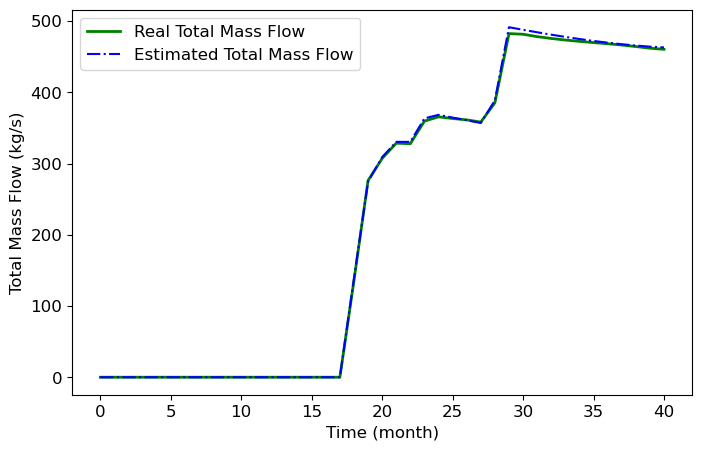

In [17]:
# Plot total flow vs found total flow
# totalFlowFound = np.zeros((T,1))
# times = range(T)
# for time in range(T):
#     tff = [wExpr[i].subs(t, time)*zReal[i,time] for i in range(n)]
#     #print(t, tff)
#     totalFlowFound[time] = sum(tff)

# plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="Real Total Mass Flow")
# plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")

# plt.title("Estimated and real total mass flows over time, with NEW solving method")
# plt.xlabel("Time (month)")
# plt.ylabel("Total Mass Flow (kg/s)")
# plt.legend()

plt.figure(figsize=(8,5))
plt.rcParams['font.size'] = 12
totalFlowFound = np.zeros((T,1))
times = range(T)
for t2 in range(T):
    tff = [wExpr[i].subs(t, t2)*zReal[i,t2] for i in range(n)]
    print(t2, tff)
    totalFlowFound[t2] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="Real Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")


#plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()
plt.savefig("LLSOoptB.svg", bbox_inches='tight')

Bayesian model based on normal distribution of provided data. Bishop book

In [18]:
# Calculate average out of sample squared error (MSE). Then sqrt
SE = 0
for i in range(n):
    for t2 in range(T):
        real = mReal[i, t2]
        estimated = zReal[i,t2]*wExpr[i].subs(t, t2)
        #print(estimated)
        RSS = (real - estimated)**2
        SE = SE + RSS

MSE = SE / n / T
RMSE = sqrt(MSE)
RMSE

In [19]:
T*(n+1)

246

In [122]:
0,-2=1.140
20,-2=1.139

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (1872975008.py, line 1)